# Code to determine the Correlations metric


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
base_dir = Path().resolve()
print(base_dir)

# utilized in upset_frequency
def load_all_league_data():
    """
    Load match data and standings for all available leagues.
    
    Returns:
        tuple: (league_data_dict, standings_dict) where each is a dict of league_name -> DataFrame
    """
    base_dir = Path().resolve()
    
    # Define league configurations
    leagues = {
        'Premier League': {
            'matches_file': 'premier_league_actual.csv',
            'standings_file': 'premier_league_standings_all_seasons.csv'
        },
        'Serie A': {
            'matches_file': 'serie_a_actual.csv',
            'standings_file': 'serie_a_standings_all_seasons.csv'
        },
        'Bundesliga': {
            'matches_file': 'bundesliga_actual.csv',
            'standings_file': 'bundesliga_standings_all_seasons.csv'
        },
        'La Liga': {
            'matches_file': 'la_liga_actual.csv',
            'standings_file': 'la_liga_standings_all_seasons.csv'
        }
    }
    
    league_data = {}
    standings_data = {}
    
    print("Loading league data...")   
    for league_name, config in leagues.items():
        # Load match data
        matches_path = base_dir / "../../../../data/european_soccer_leagues/actual" / config['matches_file']
        if matches_path.exists():
            matches_df = pd.read_csv(matches_path)
            matches_df['date'] = pd.to_datetime(matches_df['date'])
            league_data[league_name] = matches_df
            print(f"✓ Loaded {league_name} matches: {len(matches_df):,} matches")
        else:
            print(f"✗ Warning: {matches_path} not found")
            
        # Load standings data
        standings_path = base_dir / "../../../../data/european_soccer_leagues/actual" / config['standings_file']
        if standings_path.exists():
            standings_df = pd.read_csv(standings_path)
            standings_data[league_name] = standings_df
            print(f"✓ Loaded {league_name} standings: {len(standings_df):,} team-seasons")
        else:
            print(f"✗ Warning: {standings_path} not found")
    
    print(f"\nSuccessfully loaded {len(league_data)} leagues")
    return league_data, standings_data
league_data, standings_data = load_all_league_data()
len(league_data["Premier League"]["season"].unique())

/Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations
Loading league data...
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/premier_league_actual.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/premier_league_standings_all_seasons.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/serie_a_actual.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/serie_a_standings_all_seasons.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/../../../../data/european_soccer_leagues/actual/bundesliga_actual.csv not found
✗ Warning: /Users/joeyli/skillvsluck/output/european_soccer_leagues/co

KeyError: 'Premier League'

In [7]:

results = []
def goal_calculation(team, games):
    home_points = games.loc[games["home_team"] == team, "home_team_points"].sum() #sum up every home games points
    away_points = games.loc[games["away_team"] == team, "away_team_points"].sum() #sum up every away games points
    return home_points + away_points


def correlation(team,season, matches_played):
    df = matches_played[matches_played["season"] == season]
    df = df[(df["home_team"] == team) | (df["away_team"] == team)]
    df = df.sort_values(by = "date", ascending= True)
    midpoint = len(df) // 2
    first_half = df.iloc[:midpoint]
    second_half = df.iloc[midpoint:]
    first_half_points = goal_calculation(team, first_half)
    second_half_points = goal_calculation(team, second_half)
    first_half_points = (first_half_points/len(first_half))/ 3 * 100
    second_half_points = (second_half_points/len(second_half)) / 3 * 100
    dictionary= {"team": team, "season": season, "first_half_points": first_half_points, "second_half_points": second_half_points}

    return dictionary

skilled_leagues = pd.read_csv("/Users/joeyli/skillvsluck/data/european_soccer_leagues/pure_skill/skill_based_league.csv")

for league in league_data:
    # df = league_data[league] normal leagues
    df = skilled_leagues[skilled_leagues["league"] ==league].copy() # skilled leagues
    unique_pairs = set(zip(df["season"], df["home_team"]))
    for season, team in unique_pairs:
        second=correlation(team, season, df)
        second["league"] = league
        results.append(second)
allleagues = pd.DataFrame(results)
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)

In [ ]:
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)
# allleagues.to_csv("correlation_metrics.csv", index=False)
allleagues.to_csv("skill_league_correlation_metrics.csv", index=False)
allleagues


,team,season,first_half_points,second_half_points,league
910,BAY,2004,100.000000,100.000000,Bundesliga
1068,BIE,2004,29.411765,29.411765,Bundesliga
1029,BOC,2004,11.764706,11.764706,Bundesliga
936,DOR,2004,64.705882,64.705882,Bundesliga
894,FRE,2004,0.000000,0.000000,Bundesliga
...,...,...,...,...,...
878,ROM,2024,78.947368,78.947368,Serie A
575,TOR,2024,47.368421,47.368421,Serie A
874,UDI,2024,42.105263,42.105263,Serie A
574,VEN,2024,5.263158,5.263158,Serie A


In [47]:
# Testing the spearman correlations

allleagues = pd.read_csv("/Users/joeyli/skillvsluck/output/european_soccer/figures/correlations/skilled_correlations/skill_league_correlation_metrics.csv")
for league in league_data:
    #df = league_data[league] #normal leagues
    df = allleagues[allleagues["league"] ==league].copy() # skilled leagues
    spearman = df.drop(columns=["league", "team", "season"])
    corr = spearman.corr("spearman").iloc[1, 0].round(4)
    print(corr)


0.9859
0.9978
1.0
0.9994


# Create Plots

     team  season  first_half_points  second_half_points      league
0     BAY    2004         100.000000          100.000000  Bundesliga
1     BIE    2004          29.411765           29.411765  Bundesliga
2     BOC    2004          11.764706           11.764706  Bundesliga
3     DOR    2004          64.705882           64.705882  Bundesliga
4     FRE    2004           0.000000            0.000000  Bundesliga
...   ...     ...                ...                 ...         ...
1727  ROM    2024          78.947368           78.947368     Serie A
1728  TOR    2024          47.368421           47.368421     Serie A
1729  UDI    2024          42.105263           42.105263     Serie A
1730  VEN    2024           5.263158            5.263158     Serie A
1731  VER    2024          31.578947           31.578947     Serie A

[1732 rows x 5 columns]


/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_73856/4019025360.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_73856/4019025360.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_73856/4019025360.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_73856/4019025360.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


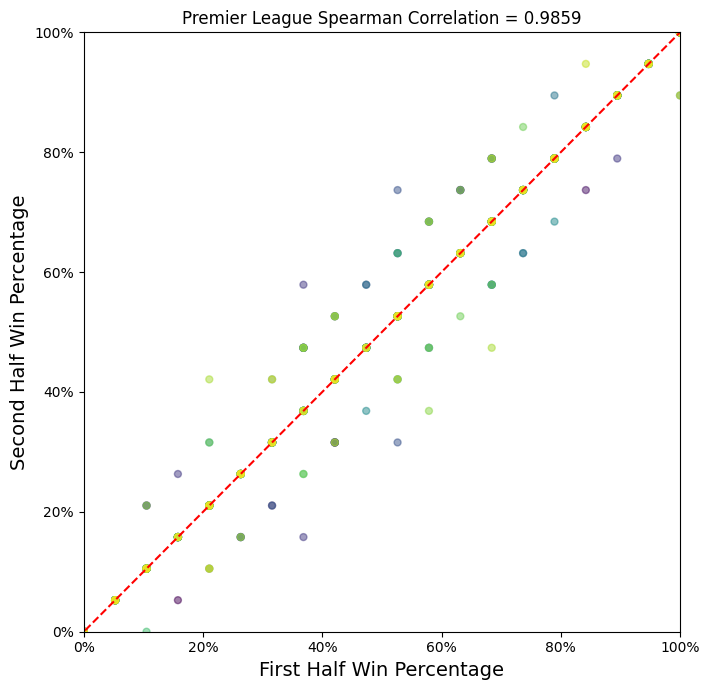

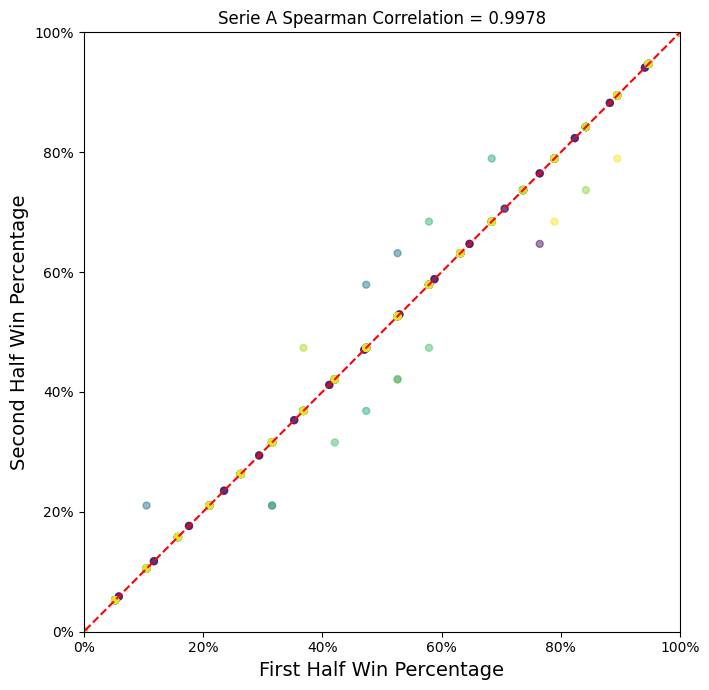

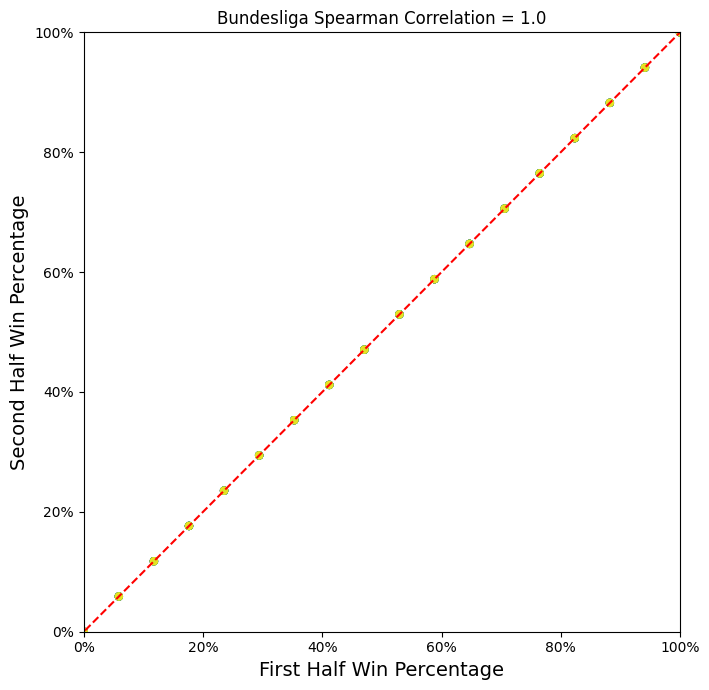

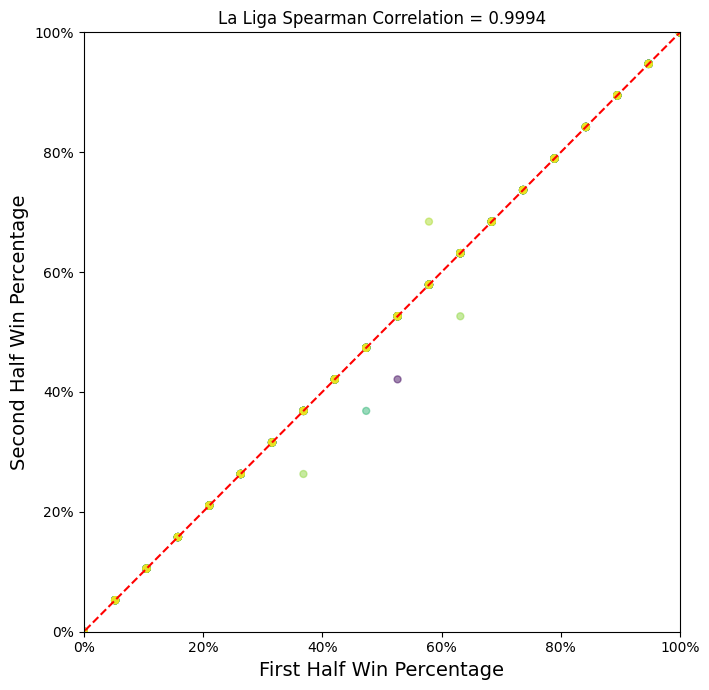

In [49]:
print(allleagues)
import matplotlib.ticker as mtick

for league in league_data:
    fig, ax = plt.subplots(figsize=(7,7), constrained_layout=True)
    df = allleagues[allleagues["league"] == league].copy()
    df["season"] = df["season"].astype(int)
    spearman = df.drop(columns=["league", "team", "season"])
    corr = spearman.corr("spearman").iloc[1, 0].round(4)
     #/ by points per game and divide by 3 to get win percentage
    

    df.plot(
        x="first_half_points", y="second_half_points", kind="scatter", ax=ax, marker='o', alpha=0.5, s=25,          # circle marker
        c=df["season"],  # 'c' instead of 'color' for a color map
        cmap="viridis"
    )
    
    # Remove the automatic colorbar
    for cbar in ax.figure.axes:
        if cbar is not ax:  # any other axes besides main one
            cbar.remove()
    # ax.set_aspect('equal', adjustable='box')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    min_val = min(plt.xlim()[0], plt.ylim()[0])
    max_val = max(plt.xlim()[1], plt.ylim()[1])
    line_vals = np.linspace(min_val, max_val, 100) # Generate points for the line
    plt.xlim(0, 100)
    plt.ylim(0, 100)

# Plot the y=x line
    plt.plot(line_vals, line_vals, color='red', linestyle='--', label='y=x')
    plt.title(f"{league} Spearman Correlation = {corr}")
    plt.xlabel("First Half Win Percentage", fontsize = 14)
    plt.ylabel("Second Half Win Percentage", fontsize = 14)
    plt.tight_layout()
    plt.savefig(f"skill_{league.replace(' ', '_').lower()}_correlation.png")




In [ ]:
import pandas as pd
from pathlib import Path

base_dir = Path("/Users/joeyli/skillvsluck/output/european_soccer_leagues/correlations/pure_luck_result_based")
csv_files = sorted(base_dir.glob("*_seed_*.csv"))

dfs = []

for file in csv_files:
    name_parts = file.stem.split("_")

    # Extract league name (everything before "first")
    if "first" in name_parts:
        league_parts = name_parts[:name_parts.index("first")]
    else:
        league_parts = name_parts[:-2]  # fallback

    league = " ".join(league_parts).title()

    # ✅ Extract seed value
    if "seed" in name_parts:
        seed_index = name_parts.index("seed")
        seed = int(name_parts[seed_index + 1])
    else:
        seed = None

    # Load CSV and add metadata
    df = pd.read_csv(file)
    df["league"] = league
    df["seed"] = seed

    dfs.append(df)
    print(f"✓ Loaded {league} seed {seed} ({len(df)} rows)")

# Combine everything
combined_df = pd.concat(dfs, ignore_index=True)

print(f"\n✅ Combined shape: {combined_df.shape}")
print(combined_df.head())

# Optional: save
output_path = base_dir / "all_leagues_combined_with_seed.csv"
combined_df.to_csv(output_path, index=False)
print(f"\nSaved combined CSV to: {output_path}")
combined_df



✓ Loaded Bundesliga seed 1 (378 rows)
✓ Loaded Bundesliga seed 2 (378 rows)
✓ Loaded La Liga seed 1 (460 rows)
✓ Loaded La Liga seed 2 (460 rows)
✓ Loaded Premier League seed 1 (440 rows)
✓ Loaded Premier League seed 2 (440 rows)
✓ Loaded Serie A seed 1 (454 rows)
✓ Loaded Serie A seed 2 (454 rows)

✅ Combined shape: (3464, 8)
       league  season team  first_half_win_pct  second_half_win_pct  n_first  \
0  Bundesliga    2004  BAY            0.529412             0.352941     17.0   
1  Bundesliga    2004  BIE            0.470588             0.352941     17.0   
2  Bundesliga    2004  BOC            0.529412             0.117647     17.0   
3  Bundesliga    2004  DOR            0.176471             0.352941     17.0   
4  Bundesliga    2004  FRE            0.176471             0.411765     17.0   

   n_second  seed  
0      17.0     1  
1      17.0     1  
2      17.0     1  
3      17.0     1  
4      17.0     1  

Saved combined CSV to: /Users/joeyli/skillvsluck/output/european_socc

,league,season,team,first_half_win_pct,second_half_win_pct,n_first,n_second,seed
0,Bundesliga,2004,BAY,0.529412,0.352941,17.0,17.0,1
1,Bundesliga,2004,BIE,0.470588,0.352941,17.0,17.0,1
2,Bundesliga,2004,BOC,0.529412,0.117647,17.0,17.0,1
3,Bundesliga,2004,DOR,0.176471,0.352941,17.0,17.0,1
4,Bundesliga,2004,FRE,0.176471,0.411765,17.0,17.0,1
...,...,...,...,...,...,...,...,...
3459,Serie A,2024,ROM,0.421053,0.315789,19.0,19.0,2
3460,Serie A,2024,TOR,0.526316,0.526316,19.0,19.0,2
3461,Serie A,2024,UDI,0.368421,0.210526,19.0,19.0,2
3462,Serie A,2024,VEN,0.315789,0.315789,19.0,19.0,2


In [10]:
df = combined_df[(combined_df["league"] == league) & (combined_df["seed"] == seed)].copy()
print(df)

       league  season  team  first_half_win_pct  second_half_win_pct  n_first  \
1216  La Liga    2000   ALA            0.578947             0.578947     19.0   
1217  La Liga    2000  ATHB            0.315789             0.473684     19.0   
1218  La Liga    2000  BARC            0.210526             0.421053     19.0   
1219  La Liga    2000   CEL            0.263158             0.263158     19.0   
1220  La Liga    2000   ESP            0.368421             0.157895     19.0   
...       ...     ...   ...                 ...                  ...      ...   
1671  La Liga    2024   RSO            0.315789             0.210526     19.0   
1672  La Liga    2024   SEV            0.473684             0.263158     19.0   
1673  La Liga    2024   VIL            0.368421             0.526316     19.0   
1674  La Liga    2024   VLC            0.315789             0.315789     19.0   
1675  La Liga    2024  VLLD            0.263158             0.421053     19.0   

      n_second  seed  
1216

/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_82283/3231936011.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_82283/3231936011.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_82283/3231936011.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_82283/3231936011.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_82283/3231936011.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_82283/3231936011.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_82283

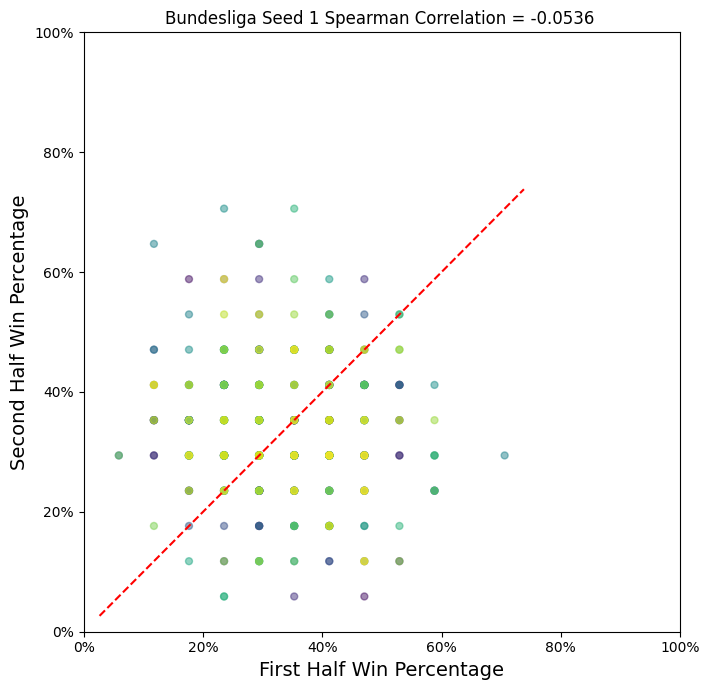

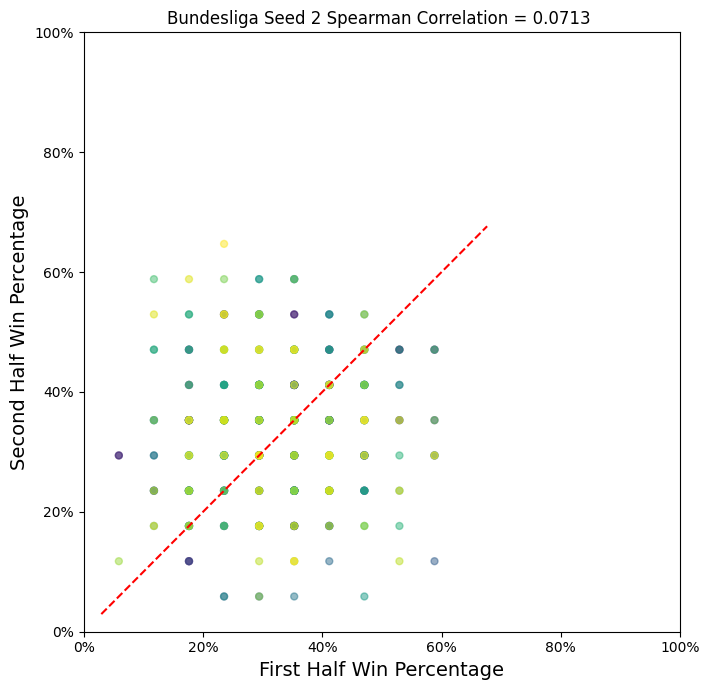

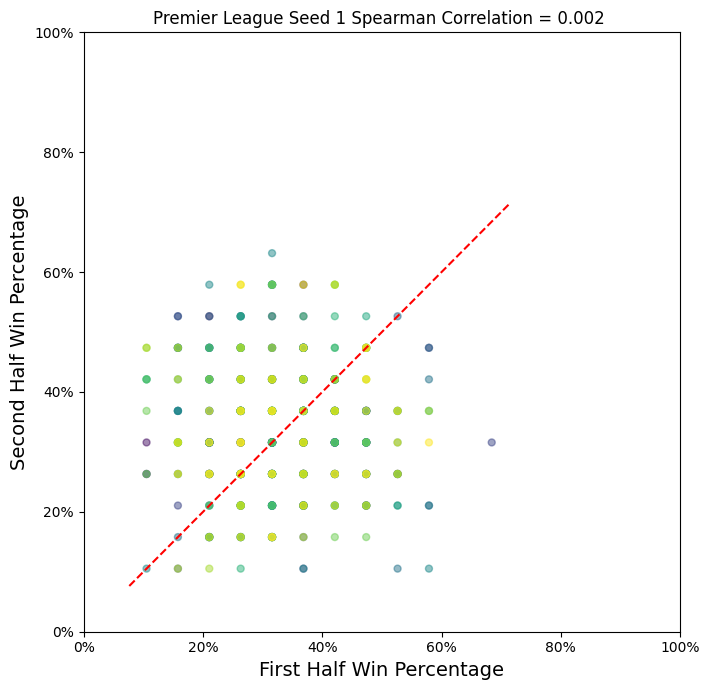

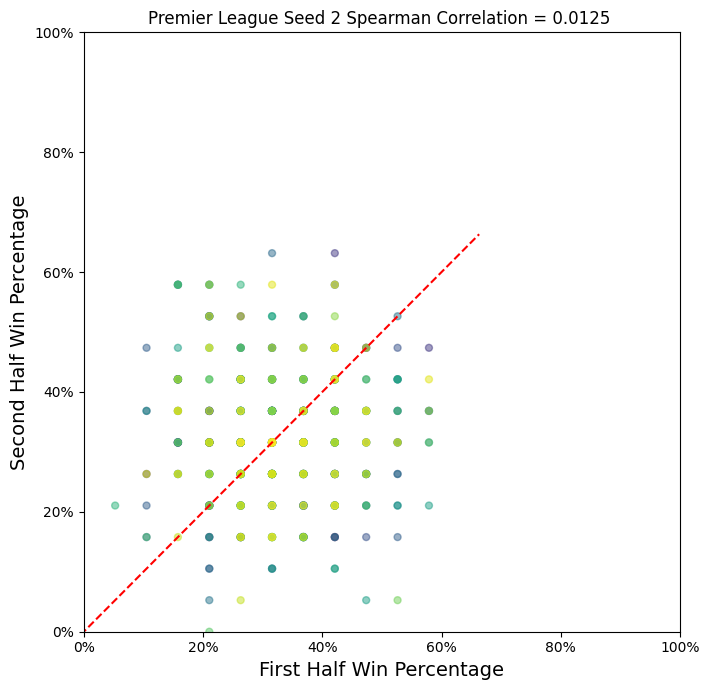

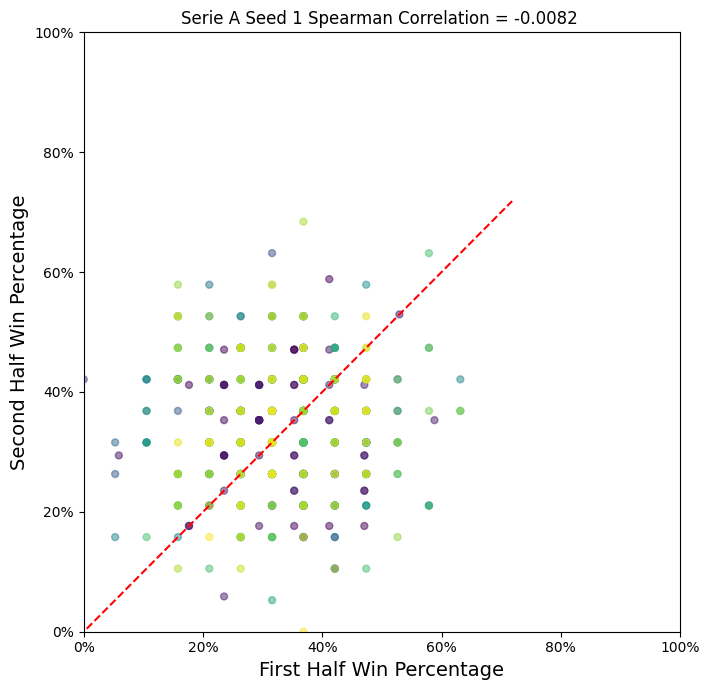

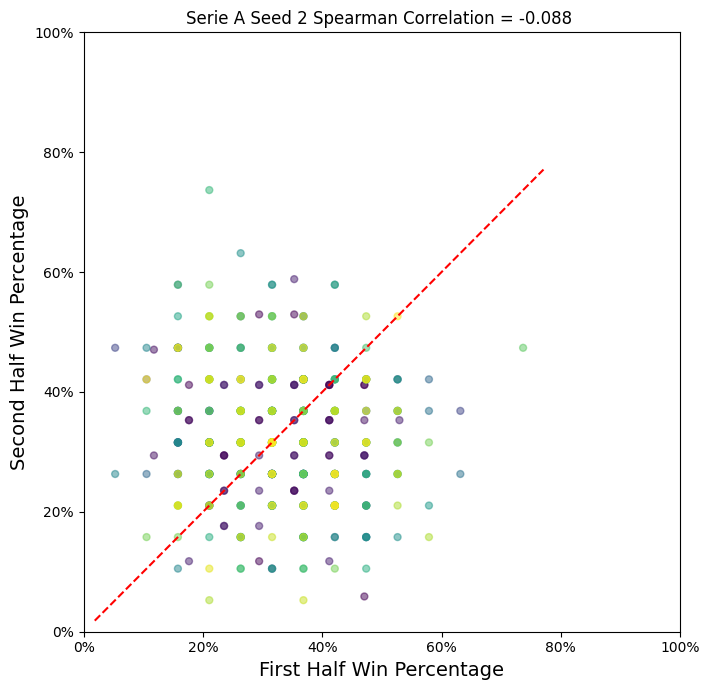

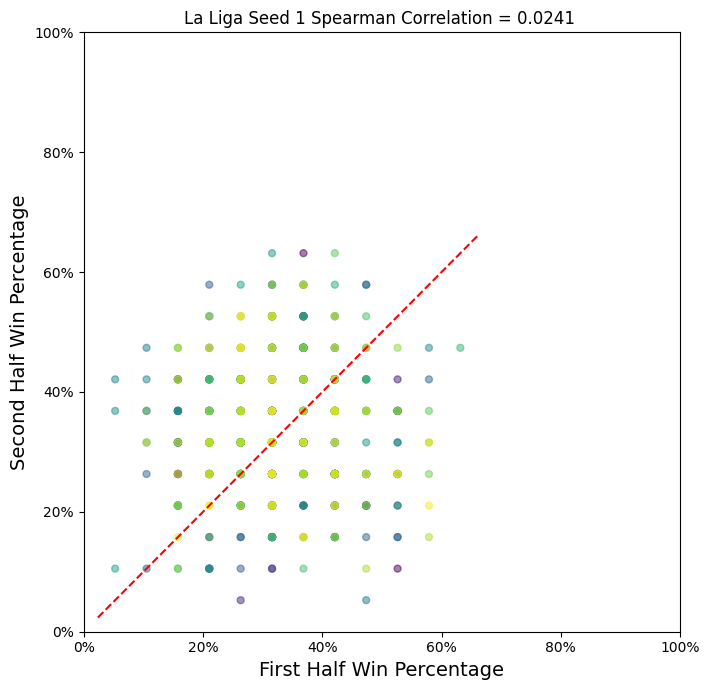

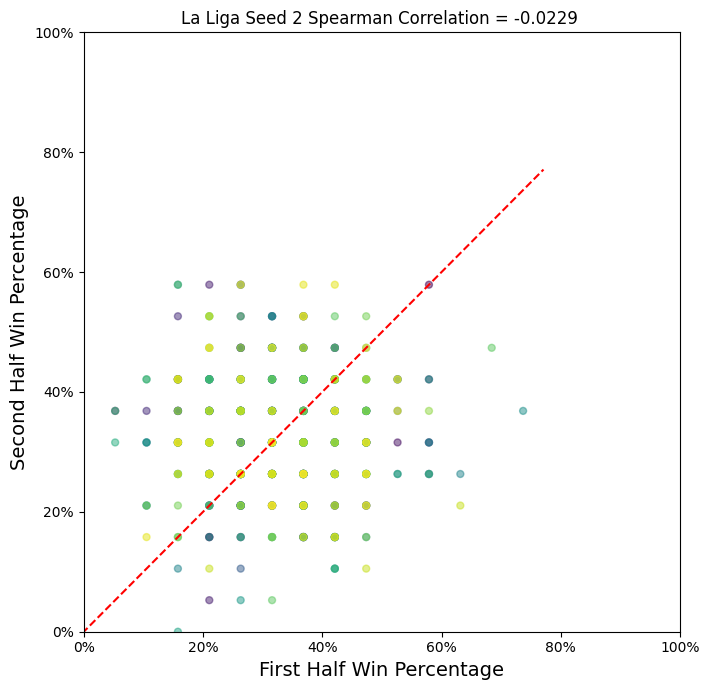

In [16]:
import matplotlib.ticker as mtick
league_data = ["Bundesliga", "Premier League", "Serie A", "La Liga"]
for league in league_data:
    for seed in [1, 2]:
        fig, ax = plt.subplots(figsize=(7,7), constrained_layout=True)
        df = combined_df[(combined_df["league"] == league) & (combined_df["seed"] == seed)].copy()
        df["season"] = df["season"].astype(int)
        df["first_half_win_pct"] = df["first_half_win_pct"] * 100
        df["second_half_win_pct"] = df["second_half_win_pct"] * 100
        spearman = df.drop(columns=["league", "team", "season", "n_first","n_second", "seed"])
        corr = spearman.corr("spearman").iloc[1, 0].round(4)
        #/ by points per game and divide by 3 to get win percentage
        

        df.plot(
            x="first_half_win_pct", y="second_half_win_pct", kind="scatter", ax=ax, marker='o', alpha=0.5, s=25,          # circle marker
            c=df["season"],  # 'c' instead of 'color' for a color map
            cmap="viridis"
        )
        
        # Remove the automatic colorbar
        for cbar in ax.figure.axes:
            if cbar is not ax:  # any other axes besides main one
                cbar.remove()
        # ax.set_aspect('equal', adjustable='box')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

        min_val = min(plt.xlim()[0], plt.ylim()[0])
        max_val = max(plt.xlim()[1], plt.ylim()[1])
        line_vals = np.linspace(min_val, max_val, 100) # Generate points for the line
        plt.xlim(0, 100)
        plt.ylim(0, 100)

    # Plot the y=x line
        plt.plot(line_vals, line_vals, color='red', linestyle='--', label='y=x')
        plt.title(f"{league} Seed {seed} Spearman Correlation = {corr} ")
        plt.xlabel("First Half Win Percentage", fontsize = 14)
        plt.ylabel("Second Half Win Percentage", fontsize = 14)
        plt.tight_layout()
        plt.savefig(f"{league.replace(' ', '_').lower()}_first_second_win_pct_seed_{seed}.png")


